In [1]:
from pathlib import Path

import pandas as pd

print("当前工作目录：", Path.cwd())
print("Pandas 版本：", pd.__version__)

当前工作目录： c:\Users\gjnzsu\Documents\ai-python-learning-pathway\projects\week-05-bike-sharing\notebooks
Pandas 版本： 2.3.3


In [2]:
DATA_PATH = Path("../data/raw/hour.csv")

print("数据绝对路径：", DATA_PATH.resolve())
print("文件是否存在：", DATA_PATH.exists())

assert DATA_PATH.exists(), f"找不到数据文件：{DATA_PATH.resolve()}"

数据绝对路径： C:\Users\gjnzsu\Documents\ai-python-learning-pathway\projects\week-05-bike-sharing\data\raw\hour.csv
文件是否存在： True


In [3]:
raw = pd.read_csv(DATA_PATH)

print("表格形状：", raw.shape)
print("字段列表：")
print(raw.columns.tolist())

表格形状： (17379, 17)
字段列表：
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


In [4]:
display(raw.head(3))
display(raw.tail(3))

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61
17378,17379,2012-12-31,1,1,12,23,0,1,1,1,0.26,0.2727,0.65,0.1343,12,37,49


In [5]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [6]:
df = raw.copy()

df["dteday"] = pd.to_datetime(
    df["dteday"],
    errors="coerce",
)

print(raw["dteday"].dtype)
print(df["dteday"].dtype)

object
datetime64[ns]


In [7]:
print("无法解析的日期数：", df["dteday"].isna().sum())
print("最早日期：", df["dteday"].min())
print("最晚日期：", df["dteday"].max())
print("日期是否按升序排列：", df["dteday"].is_monotonic_increasing)

无法解析的日期数： 0
最早日期： 2011-01-01 00:00:00
最晚日期： 2012-12-31 00:00:00
日期是否按升序排列： True


In [8]:
df["timestamp"] = (
    df["dteday"]
    + pd.to_timedelta(df["hr"], unit="h")
)

display(df[["dteday", "hr", "timestamp"]].head(26))

print("时间戳是否唯一：", df["timestamp"].is_unique)
print("重复时间戳数量：", df["timestamp"].duplicated().sum())
print("时间戳是否升序：", df["timestamp"].is_monotonic_increasing)

time_differences = df["timestamp"].diff()

print(time_differences.value_counts().sort_index().head(10))
print("不是连续一小时的间隔数：", time_differences.ne(pd.Timedelta(hours=1)).sum())

,dteday,hr,timestamp
0,2011-01-01,0,2011-01-01 00:00:00
1,2011-01-01,1,2011-01-01 01:00:00
2,2011-01-01,2,2011-01-01 02:00:00
3,2011-01-01,3,2011-01-01 03:00:00
4,2011-01-01,4,2011-01-01 04:00:00
5,2011-01-01,5,2011-01-01 05:00:00
6,2011-01-01,6,2011-01-01 06:00:00
7,2011-01-01,7,2011-01-01 07:00:00
8,2011-01-01,8,2011-01-01 08:00:00
9,2011-01-01,9,2011-01-01 09:00:00


时间戳是否唯一： True
重复时间戳数量： 0
时间戳是否升序： True
timestamp
0 days 01:00:00    17303
0 days 02:00:00       64
0 days 03:00:00        6
0 days 07:00:00        1
0 days 13:00:00        1
0 days 14:00:00        1
0 days 23:00:00        1
1 days 13:00:00        1
Name: count, dtype: int64
不是连续一小时的间隔数： 76


In [9]:
actual_gaps = time_differences.iloc[1:]

missing_hours = (
    actual_gaps
    .sub(pd.Timedelta(hours=1))
    .div(pd.Timedelta(hours=1))
    .sum()
)

print("实际缺失小时数：", int(missing_hours))

实际缺失小时数： 165


In [10]:
expected_hours = pd.date_range(
    start=df["timestamp"].min(),
    end=df["timestamp"].max(),
    freq="h",
)

print("理论小时数：", len(expected_hours))
print("实际记录数：", len(df))
print("缺失小时数：", len(expected_hours) - len(df))

理论小时数： 17544
实际记录数： 17379
缺失小时数： 165


In [11]:
missing_timestamps = expected_hours.difference(
    pd.DatetimeIndex(df["timestamp"])
)

print(missing_timestamps[:20])

DatetimeIndex(['2011-01-02 05:00:00', '2011-01-03 02:00:00',
               '2011-01-03 03:00:00', '2011-01-04 03:00:00',
               '2011-01-05 03:00:00', '2011-01-06 03:00:00',
               '2011-01-07 03:00:00', '2011-01-11 03:00:00',
               '2011-01-11 04:00:00', '2011-01-12 03:00:00',
               '2011-01-12 04:00:00', '2011-01-14 04:00:00',
               '2011-01-18 00:00:00', '2011-01-18 01:00:00',
               '2011-01-18 02:00:00', '2011-01-18 03:00:00',
               '2011-01-18 04:00:00', '2011-01-18 05:00:00',
               '2011-01-18 06:00:00', '2011-01-18 07:00:00'],
              dtype='datetime64[ns]', freq=None)


In [12]:
missing_by_hour = (
    pd.Series(missing_timestamps.hour, name="hour")
    .value_counts()
    .sort_index()
)

print(missing_by_hour)

hour
0      5
1      7
2     16
3     34
4     34
5     14
6      6
7      4
8      4
9      4
10     4
11     4
12     3
13     2
14     2
15     2
16     1
17     1
18     3
19     3
20     3
21     3
22     3
23     3
Name: count, dtype: int64


In [13]:
missing_by_year = (
    pd.Series(missing_timestamps.year, name="year")
    .value_counts()
    .sort_index()
)

missing_by_month = (
    pd.Series(missing_timestamps.month, name="month")
    .value_counts()
    .sort_index()
)

print("按年份：")
print(missing_by_year)

print("\n按月份：")
print(missing_by_month)

按年份：
year
2011    115
2012     50
Name: count, dtype: int64

按月份：
month
1     59
2     27
3     15
4      3
8     13
9      3
10    37
11     3
12     5
Name: count, dtype: int64


In [14]:
missing_df = pd.DataFrame(
    {
        "timestamp": missing_timestamps,
        "year": missing_timestamps.year,
        "month": missing_timestamps.month,
        "hour": missing_timestamps.hour,
    }
)

missing_pattern = pd.crosstab(
    missing_df["year"],
    missing_df["hour"],
)

display(missing_pattern)

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
year,,,,,,,,,,,,,,,,,,,,,
2011,4,5,13,23,28,12,4,2,2,2,...,1,1,0,0,2,2,2,2,2,2
2012,1,2,3,11,6,2,2,2,2,2,...,1,1,1,1,1,1,1,1,1,1


In [15]:
print("最小租赁量：", df["cnt"].min())
print("零租赁记录数：", df["cnt"].eq(0).sum())
print("租赁量为 1 的记录数：", df["cnt"].eq(1).sum())

最小租赁量： 1
零租赁记录数： 0
租赁量为 1 的记录数： 158


In [16]:
DAY_DATA_PATH = Path("../data/raw/day.csv")

day_df = pd.read_csv(
    DAY_DATA_PATH,
    parse_dates=["dteday"],
)

print(day_df.shape)
print(day_df["dteday"].is_unique)

(731, 16)
True


In [17]:
hour_daily = (
    df.groupby("dteday", as_index=False)
    .agg(
        casual_from_hour=("casual", "sum"),
        registered_from_hour=("registered", "sum"),
        cnt_from_hour=("cnt", "sum"),
        observed_hours=("hr", "size"),
    )
)

display(hour_daily.head())

,dteday,casual_from_hour,registered_from_hour,cnt_from_hour,observed_hours
0,2011-01-01,331,654,985,24
1,2011-01-02,131,670,801,23
2,2011-01-03,120,1229,1349,22
3,2011-01-04,108,1454,1562,23
4,2011-01-05,82,1518,1600,23


In [18]:
daily_comparison = day_df[
    ["dteday", "casual", "registered", "cnt"]
].merge(
    hour_daily,
    on="dteday",
    how="outer",
    validate="one_to_one",
    indicator=True,
)

print(daily_comparison["_merge"].value_counts())

_merge
both          731
left_only       0
right_only      0
Name: count, dtype: int64


In [19]:
daily_comparison["casual_matches"] = daily_comparison[
    "casual"
].eq(daily_comparison["casual_from_hour"])

daily_comparison["registered_matches"] = daily_comparison[
    "registered"
].eq(daily_comparison["registered_from_hour"])

daily_comparison["cnt_matches"] = daily_comparison[
    "cnt"
].eq(daily_comparison["cnt_from_hour"])

print(
    daily_comparison[
        ["casual_matches", "registered_matches", "cnt_matches"]
    ].all()
)

casual_matches        True
registered_matches    True
cnt_matches           True
dtype: bool


In [20]:
incomplete_days = daily_comparison.loc[
    daily_comparison["observed_hours"].lt(24),
    [
        "dteday",
        "observed_hours",
        "cnt",
        "cnt_from_hour",
        "cnt_matches",
    ],
]

display(incomplete_days.head(20))
print("不足24条小时记录的日期数：", len(incomplete_days))

,dteday,observed_hours,cnt,cnt_from_hour,cnt_matches
1,2011-01-02,23,801,801,True
2,2011-01-03,22,1349,1349,True
3,2011-01-04,23,1562,1562,True
4,2011-01-05,23,1600,1600,True
5,2011-01-06,23,1606,1606,True
6,2011-01-07,23,1510,1510,True
10,2011-01-11,22,1263,1263,True
11,2011-01-12,22,1162,1162,True
13,2011-01-14,23,1421,1421,True
17,2011-01-18,12,683,683,True


不足24条小时记录的日期数： 76


In [21]:
audit = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_rate": df.isna().mean(),
        "unique_count": df.nunique(dropna=False),
    }
)

display(
    audit.sort_values(
        ["missing_rate", "unique_count"],
        ascending=[False, True],
    )
)

,dtype,missing_count,missing_rate,unique_count
yr,int64,0,0.0,2
holiday,int64,0,0.0,2
workingday,int64,0,0.0,2
season,int64,0,0.0,4
weathersit,int64,0,0.0,4
weekday,int64,0,0.0,7
mnth,int64,0,0.0,12
hr,int64,0,0.0,24
windspeed,float64,0,0.0,30
temp,float64,0,0.0,50


In [22]:
print("完整重复行：", df.duplicated().sum())

print(
    "日期和小时重复：",
    df.duplicated(subset=["dteday", "hr"]).sum(),
)

print("instant 是否唯一：", df["instant"].is_unique)

完整重复行： 0
日期和小时重复： 0
instant 是否唯一： True


In [23]:
assert df["season"].isin([1, 2, 3, 4]).all()
assert df["yr"].isin([0, 1]).all()
assert df["mnth"].between(1, 12).all()
assert df["hr"].between(0, 23).all()
assert df["holiday"].isin([0, 1]).all()
assert df["weekday"].between(0, 6).all()
assert df["workingday"].isin([0, 1]).all()
assert df["weathersit"].isin([1, 2, 3, 4]).all()

In [24]:
normalized_columns = [
    "temp",
    "atemp",
    "hum",
    "windspeed",
]

for column in normalized_columns:
    assert df[column].between(0, 1).all(), column

In [25]:
count_columns = [
    "casual",
    "registered",
    "cnt",
]

for column in count_columns:
    assert df[column].ge(0).all(), column

In [26]:
count_matches = df["cnt"].eq(
    df["casual"] + df["registered"]
)

print(count_matches.value_counts())
assert count_matches.all()

True    17379
Name: count, dtype: int64


In [27]:
numeric_columns = [
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "casual",
    "registered",
    "cnt",
]

summary = df[numeric_columns].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]
).T

display(summary)

,count,mean,std,min,25%,50%,75%,95%,99%,max
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,0.8000,0.8844,1.0000
atemp,17379.0,0.475775,0.171850,0.00,0.3333,0.4848,0.6212,0.7424,0.8182,1.0000
hum,17379.0,0.627229,0.192930,0.00,0.4800,0.6300,0.7800,0.9300,1.0000,1.0000
windspeed,17379.0,0.190098,0.122340,0.00,0.1045,0.1940,0.2537,0.4179,0.5224,0.8507
casual,17379.0,35.676218,49.305030,0.00,4.0000,17.0000,48.0000,138.1000,240.0000,367.0000
registered,17379.0,153.786869,151.357286,0.00,34.0000,115.0000,220.0000,465.0000,699.2200,886.0000
cnt,17379.0,189.463088,181.387599,1.00,40.0000,142.0000,281.0000,563.1000,782.2200,977.0000


In [28]:
hourly = (
    df.groupby("hr", as_index=False)
    .agg(
        sample_count=("cnt", "size"),
        median_rentals=("cnt", "median"),
        mean_rentals=("cnt", "mean"),
    )
)

display(hourly)

,hr,sample_count,median_rentals,mean_rentals
0,0,726,40.0,53.898072
1,1,724,20.0,33.375691
2,2,715,11.0,22.869930
3,3,697,6.0,11.727403
4,4,697,6.0,6.352941
5,5,717,19.0,19.889819
6,6,725,76.0,76.044138
7,7,727,208.0,212.064649
8,8,727,385.0,359.011004
9,9,727,216.0,219.309491


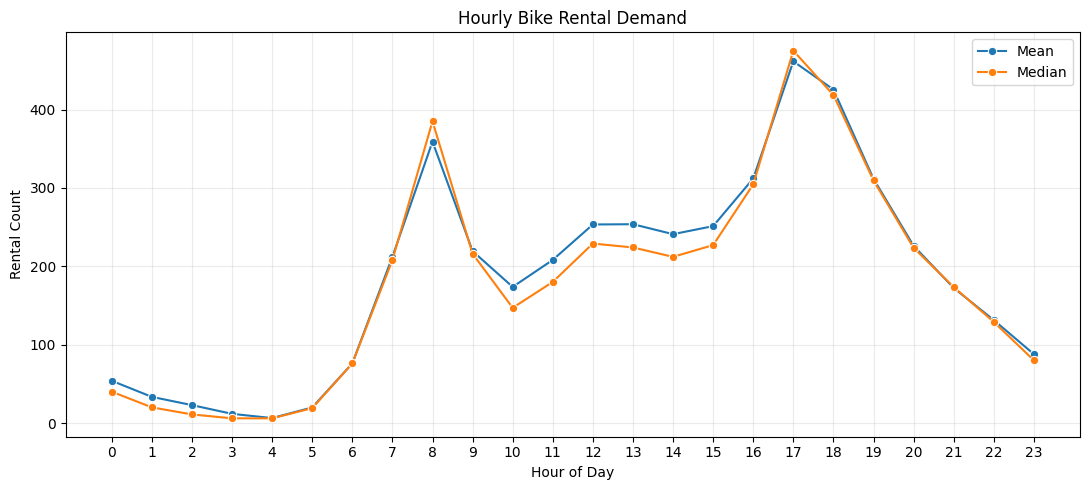

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(11, 5))

sns.lineplot(
    data=hourly,
    x="hr",
    y="mean_rentals",
    marker="o",
    label="Mean",
    ax=ax,
)

sns.lineplot(
    data=hourly,
    x="hr",
    y="median_rentals",
    marker="o",
    label="Median",
    ax=ax,
)

ax.set(
    title="Hourly Bike Rental Demand",
    xlabel="Hour of Day",
    ylabel="Rental Count",
)

ax.set_xticks(range(24))
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

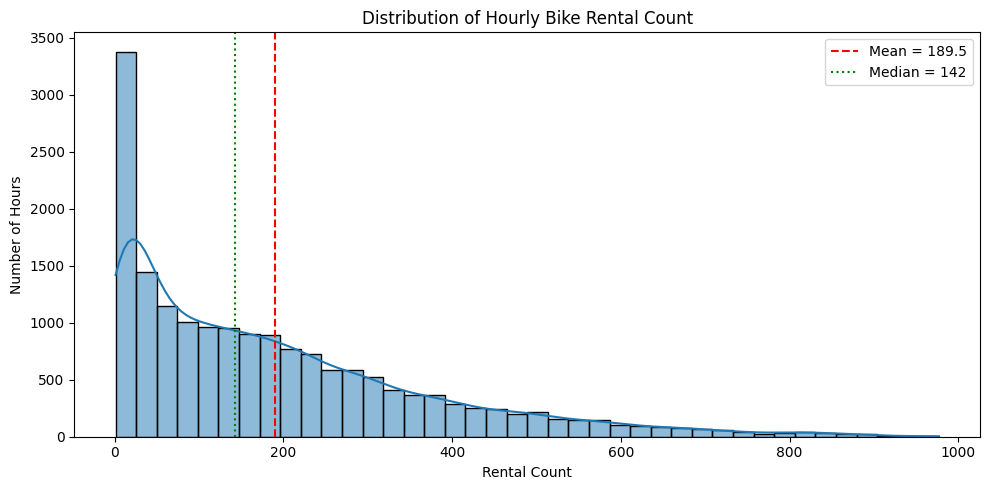

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=df,
    x="cnt",
    bins=40,
    kde=True,
    ax=ax,
)

ax.axvline(
    df["cnt"].mean(),
    color="red",
    linestyle="--",
    label=f'Mean = {df["cnt"].mean():.1f}',
)

ax.axvline(
    df["cnt"].median(),
    color="green",
    linestyle=":",
    label=f'Median = {df["cnt"].median():.0f}',
)

ax.set(
    title="Distribution of Hourly Bike Rental Count",
    xlabel="Rental Count",
    ylabel="Number of Hours",
)

ax.legend()
plt.tight_layout()
plt.show()

In [31]:
hourly_by_workingday = (
    df.groupby(["workingday", "hr"], as_index=False)
    .agg(
        sample_count=("cnt", "size"),
        median_rentals=("cnt", "median"),
        mean_rentals=("cnt", "mean"),
    )
)

hourly_by_workingday["day_type"] = (
    hourly_by_workingday["workingday"]
    .map({
        0: "Non-working day",
        1: "Working day",
    })
)

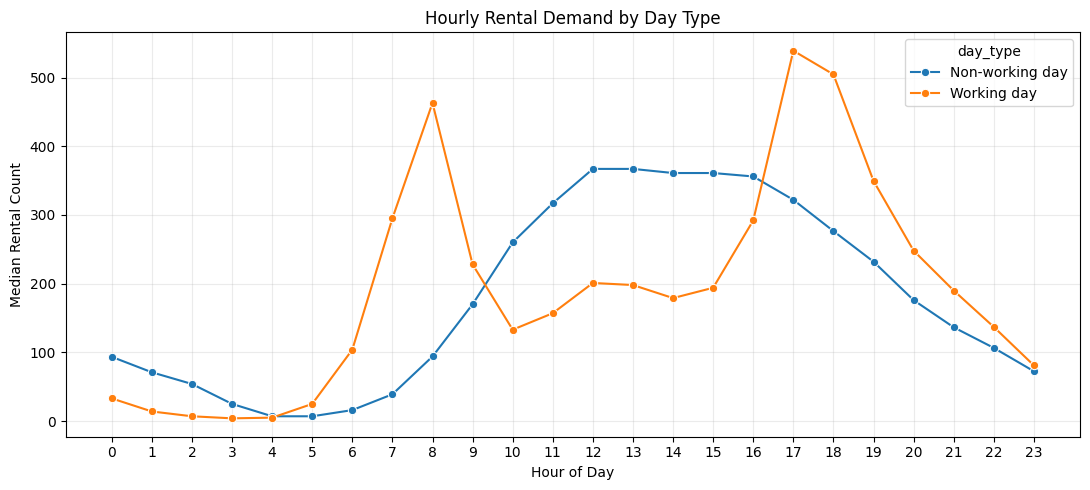

In [32]:
fig, ax = plt.subplots(figsize=(11, 5))

sns.lineplot(
    data=hourly_by_workingday,
    x="hr",
    y="median_rentals",
    hue="day_type",
    marker="o",
    ax=ax,
)

ax.set(
    title="Hourly Rental Demand by Day Type",
    xlabel="Hour of Day",
    ylabel="Median Rental Count",
)

ax.set_xticks(range(24))
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### 观察

工作日租赁需求在 08:00 和 17:00–18:00 出现明显双峰，
而非工作日的需求高峰较平缓，主要集中在中午至下午。
该模式与早晚通勤和非工作日休闲骑行的解释一致。

### 限制

`workingday=0` 同时包含周末和法定节假日，二者可能具有不同模式。
数据没有记录用户的出行目的，因此不能证明高峰租赁一定用于通勤。
图中还混合了不同年份、季节和天气条件。

### 下一步

分别比较周末与法定节假日，并按年份、季节和天气状况分层，
检查该小时模式是否稳定。